In [6]:


import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt
import tensorflow as tf


import kagglehub


In [48]:
!pip install mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 99.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 12.9 MB/s eta 0:00:00


In [7]:


TRAIN_DIR = "/kaggle/input/datasets/edoardovantaggiato/covid19-xray-two-proposed-databases/Datasets/3-classes/Train"
VAL_DIR = "/kaggle/input/datasets/edoardovantaggiato/covid19-xray-two-proposed-databases/Datasets/3-classes/Val"
TEST_DIR = "/kaggle/input/datasets/edoardovantaggiato/covid19-xray-two-proposed-databases/Datasets/3-classes/Test"

print("Checking dataset...")


print("Train path:",os.path.exists(TRAIN_DIR))
print("Validation path:",os.path.exists(VAL_DIR))
print("Test path:",os.path.exists(TEST_DIR))

Checking dataset...
Train path: True
Validation path: True
Test path: True


In [16]:
# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

SEED = 42

#LOading Datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1212 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 621 files belonging to 3 classes.


In [18]:
class_names = train_dataset.class_names

NUM_CLASSES = len(class_names)


print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['Covid-19', 'Normal', 'Pneumonia']
Number of classes: 3


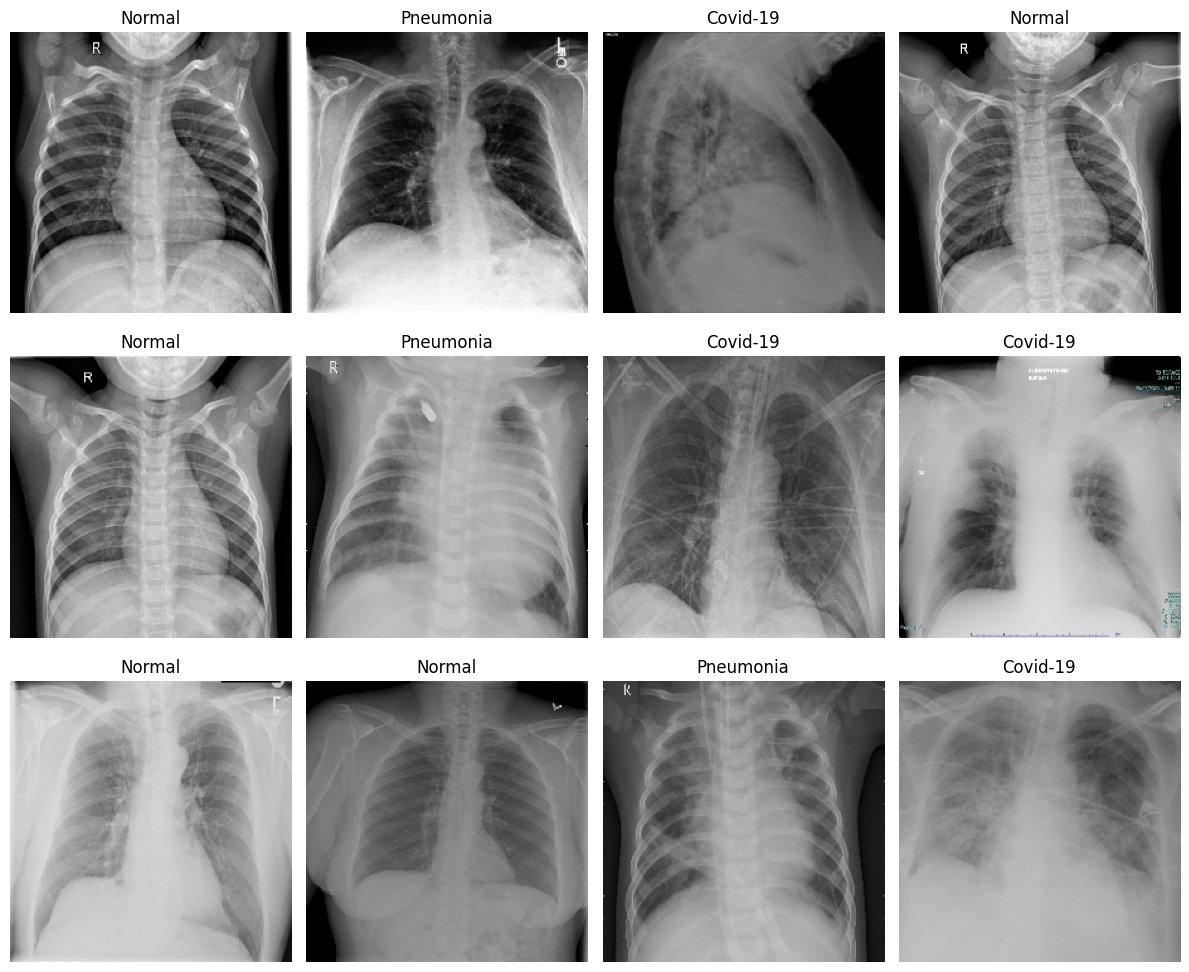

In [19]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):

    for i in range(min(12, len(images))):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [21]:



AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)


In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns


data_augmentation = tf.keras.Sequential([
    
    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05 ),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

], name="data_augmentation")


In [39]:
# model Building

model = models.Sequential([

    # Input layer
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), 
    data_augmentation,
    
    layers.Rescaling(1.0 / 255),
    
    layers.Conv2D(filters=32,kernel_size=(3, 3),activation="relu",padding="same", kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64,kernel_size=(3, 3),activation="relu",padding="same",kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
   
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same",kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D( filters=256,kernel_size=(3, 3),activation="relu",padding="same", kernel_regularizer=l2_reg),
    layers.BatchNormalization(),
    layers.MaxPooling2D( pool_size=(2, 2)),

    layers.SpatialDropout2D(0.30),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128,activation="relu",kernel_regularizer=l2_reg),
    layers.BatchNormalization(),

    layers.Dropout(0.40),

    layers.Dense(NUM_CLASSES,activation="softmax")

])

model.summary()




Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,131 (1.62 MB)

 Trainable params: 422,915 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy" ])


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)


model_checkpoint = ModelCheckpoint(

    "best_cnn_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-7,

    verbose=1
)


In [ ]:
print("\nStarting CNN training...\n")

EPOCHS=10

import mlflow.tensorflow

# Disable saving the model artifacts
mlflow.tensorflow.autolog(log_models=False)

with mlflow.start_run():
    
    mlflow.set_tag("run_purpose", "Fixing overfitting on CT scans")
    mlflow.set_tag("architecture_changes", "Added L2 reg (1e-4) in all Conv2D and SpatialDropout(0.30)")
    #mlflow.set_tag("dataset_issue", "Ensured no patient leakage between train/val")

    
    history = model.fit(
    
        train_dataset,
    
        validation_data=val_dataset,
    
        epochs=EPOCHS,
    
        callbacks=[
            early_stopping,
            model_checkpoint,
            reduce_lr
        ]
    
    )

    
    fig_acc = plt.figure(figsize=(10, 6))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    
    # Save directly to MLflow (no local file needed)
    mlflow.log_figure(fig_acc, "visualizations/accuracy_curve.png")
    
    # Clear the figure from memory so they don't overlap
    plt.show()
    plt.close(fig_acc)


    fig_loss = plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    
    # Save the second plot to MLflow
    mlflow.log_figure(fig_loss, "visualizations/loss_curve.png")
    
    # Clear the memory
    plt.show()
    plt.close(fig_loss)


    
    test_loss, test_accuracy = model.evaluate(test_dataset)
    
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Test Accuracy  : {test_accuracy:.4f}")
    print(f"Test Accuracy  : {test_accuracy * 100:.2f}%")
    
    # Add these two lines to save the test scores into MLflow!
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metrics("Test Accuracy%",(test_accuracy * 100))
    

In [53]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/08/29 14:09:33 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/08/29 14:09:33 INFO:     Started parent process [1510]
2026/08/29 14:09:40 INFO:     Started server process [1515]
2026/08/29 14:09:40 INFO:     Waiting for application startup.
2026/08/29 14:09:40 INFO:     Application startup complete.
2026/08/29 14:09:41 INFO:     Started server process [1516]
2026/08/29 14:09:41 INFO:     Waiting for application startup.
2026/08/29 14:09:41 INFO:     Application startup complete.
2026/08/29 14:09:41 INFO:     Started server process [1513]
2026/08/29 14:09:41 INFO:     Waiting for application startup.
2026/08/29 14:09:41 INFO:     Application startu

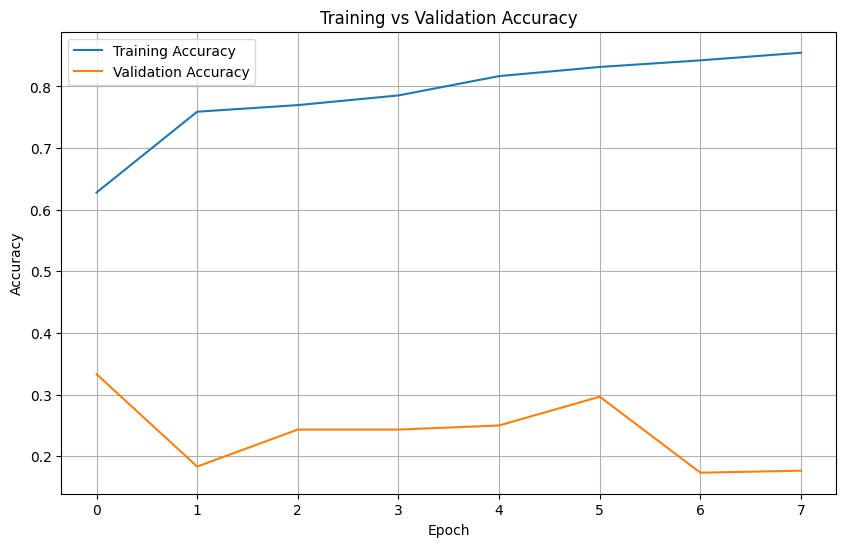

In [44]:

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid()

plt.show()

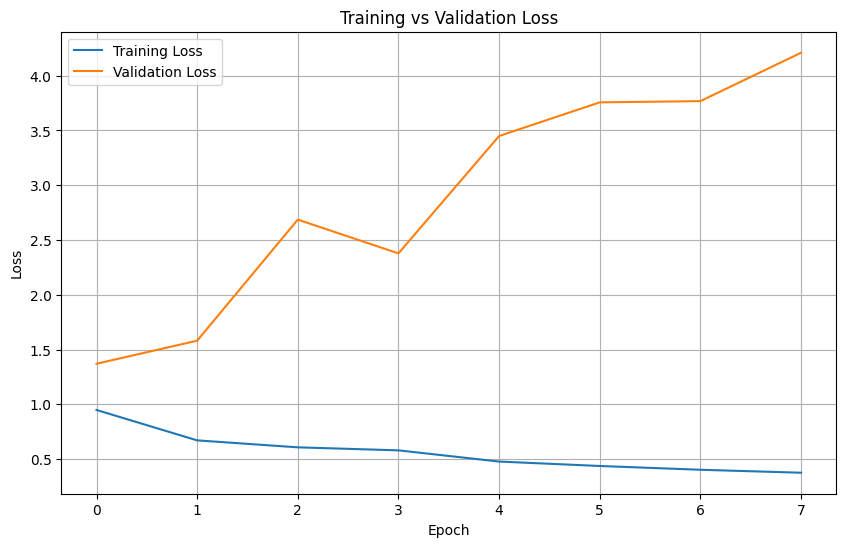

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
model = tf.keras.models.load_model("best_cnn_model.keras")

print("\nBest model loaded successfully!")

In [46]:

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")

print(f"Test Accuracy : {test_accuracy:.4f}")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.3333 - loss: 1.2942
Test Loss     : 1.2942
Test Accuracy : 0.3333
Test Accuracy : 33.33%


In [ ]:


y_true = []
y_pred = []


for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(y_true)

y_pred = np.array(y_pred)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix"
)

plt.show()


# ============================================================
# 23. SAVE FINAL MODEL
# ============================================================

model.save(
    "cnn_medical_image_classifier.keras"
)

print(
    "\nModel saved as cnn_medical_image_classifier.keras"
)


# ============================================================
# 24. SAVE CLASS NAMES
# ============================================================

import json

with open(
    "class_names.json",
    "w"
) as f:

    json.dump(
        class_names,
        f
    )

print(
    "Class names saved as class_names.json"
)


# ============================================================
# 25. SINGLE IMAGE PREDICTION FUNCTION
# ============================================================

def predict_image(
    image_path,
    model,
    class_names
):

    # Load image
    img = image.load_img(

        image_path,

        target_size=IMAGE_SIZE
    )


    # Convert image to array
    img_array = image.img_to_array(
        img
    )


    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )


    # Predict
    predictions = model.predict(
        img_array,
        verbose=0
    )


    # Get predicted class
    predicted_index = np.argmax(
        predictions[0]
    )


    predicted_class = class_names[
        predicted_index
    ]


    confidence = predictions[
        0
    ][predicted_index]


    print("\n====================================")
    print("IMAGE PREDICTION")
    print("====================================")

    print(
        "Predicted Class:",
        predicted_class
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )


    # Display image
    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        img
    )

    plt.title(
        f"{predicted_class} "
        f"({confidence * 100:.2f}%)"
    )

    plt.axis("off")

    plt.show()


    return predicted_class, confidence


# ============================================================
# 26. EXAMPLE SINGLE IMAGE PREDICTION
# ============================================================

# Replace this with your image path.

# image_path = "sample_xray.jpg"

# predict_image(
#     image_path,
#     model,
#     class_names
# )


# ============================================================
# 27. PREDICT ALL TEST IMAGES
# ============================================================

print("\nPrediction completed for all test images.")

